## 7. 现代卷积神经网络

- 卷积神经网络可以说是面向计算机视觉的一个架构，而提到计算机视觉，绕不开的一个话题就是ImageNet竞赛

- 本章主要围绕一些“现代”的卷积神经网络架构，之所以给“现代”这个词打上引号，很大的原因在于这些架构都是在d2l成书当时比较流形和熟悉的架构，在这些年当中，这个领域又出现了很多其他的工作

- 本章主要介绍的模型包括：
    - AlexNet，这是第一个在ImageNet中击败传统计算机视觉模型的大型神经网络
    - VGG，利用许多重复的神经网络块
    - NiN，重复使用卷积层和1*1卷积层构建深层网络
    - GoogleNet，使用并行连结的网络，通过不同大小的卷积核并行抽取信息
    - ResNet，通过残差块构建跨层的数据通道
    - DenseNet，计算成本高但效果更好的网络设计
    - 批量规范化(batch normalization)技术的使用

### 7.1 深度卷积神经网络(AlexNet)

- LeNet虽然效果优异，但成功建立在小数据集上，在更大、更真实的数据集中并未得到证实

- 相较于传统的机器学习，推崇卷积神经网络类似架构的计算机视觉研究人员思考问题的角度有所不同：
    - 传统机器学习的pipeline类似：
        - 收集一个具有针对性的数据集
        - 手工对特征数据集进行预处理
        - 通过标准的特征提取算法处理数据，换言之传统机器学习方法输入模型的一定不是raw data
        - 根据理论证明模型的性质，在特定的模型中训练分类器
    - 但CV的研究人员更笃定大而干净的数据集、优秀的数据提取远比优雅的理论证明、学习算法的改进带来的进步大得多

#### 7.1.1 学习表征

- 说明这两条路线一个很好的解决思路就是查看图像特征的提取方法
    - 在2012年前,图像特征都是机械地计算出来的。事实上,设计一套新的特征函数、改进结果,并撰写论文是盛极一时的潮流。SIFT(Lowe, 2004)、SURF(Bay et al., 2006)、HOG(定向梯度直方图)(Dalal and Triggs, 2005)、bags of visual words和类似的特征提取方法占据了主导地位
    - Yann LeCun、Geoff Hinton、Yoshua Bengio、Andrew Ng、Shun ichi Amari和Juergen Schmidhuber等则看法不同：**特征本身应该被学习**
        - 此外，特征还应该由多个共同学习的神经网络层组成，每个层都有学习的参数
        - 模型的底层应该尽可能地去检测边缘、颜色和纹理等信息(更靠近输入的部分)
    - AlexNet在2012年的ImageNet挑战赛中取得了非常好的成绩，在网络的底层就学习到了一些类似传统滤波器的特征提取器，如下图
        - ![7.1](./images/chapter7/1.png)
    - AlexNet的更高层学习到的特征更为高级，类似围绕一个图像中的具体元素等等

- 类似的路线一直有人钻研，但最终在2012年的时间节点由AlexNet突破，d2l中将这个突破归因于两个关键因素
    - 数据：
        - 包含许多特征的深度模型需要大量的有标签数据，但早期的大部分研究只基于小型的公开数据集
        - 2009年,ImageNet数据集发布,并发起ImageNet挑战赛:要求研究人员从100万个样本中训练模型,以区分1000个不同类别的对象。
            - ImageNet数据集由斯坦福教授李飞飞小组的研究人员开发,利用谷歌图像搜索(Google Image Search)对每一类图像进行预筛选,并利用亚马逊众包(Amazon Mechanical Turk)来标注每张图片的相关类别
    - 硬件：
        - 深度学习对计算资源要求很高，因此在机器学习的早期研究人员更倾向于优化凸目标的简单算法
        - GPU的出现改变了这一格局
            - CPU中每个核心都具有高时钟频率的运行能力和L3Cache，但正因为CPU可以执行各种指令，通用核心的特点也使得在单个任务上的性能相对较差
            - GPU中有上千个处理单元(目前Hopper架构和Blackwell架构的tensor核心已是两万左右)，这些处理单元虽然单个核心的时钟频率较低，但庞大的数量和成组(warps)的计算方式使GPU的浮点性能相较于CPU大幅提升
    - 回到2012年的重大突破,当Alex Krizhevsky和Ilya Sutskever实现了可以在GPU硬件上运行的深度卷积神经网络时,一个重大突破出现了。他们意识到卷积神经网络中的计算瓶颈:卷积和矩阵乘法,都是可以在硬件上并行化的操作。于是,他们使用两个显存为3GB的NVIDIA GTX580 GPU实现了快速卷积运算。

#### 7.1.2 AlexNet

- AlexNet和LeNet的架构非常类似，d2l中呈现的是一个简化版本，原始的AlexNet因为需要在两张卡上并行运算，因此有一些其他的组件

- 简化的AlexNet和LeNet的结构对比如图：
    - ![7.2](./images/chapter7/2.png)

- AlexNet比相对较小的LeNet5要深得多。AlexNet由八层组成:五个卷积层、两个全连接隐藏层和一个全连接输出层；AlexNet使用ReLU而不是sigmoid作为激活函数

- 这张图和这里介绍的AlexNet，最大的不同就是真实的实现中的第一个和第二个卷积层都是在两张GPU上并行均分的，在通道维度上做了切分以便能在GPU上顺利运行

- 模型设计
    - 在AlexNet的第一层,卷积窗口的形状是11×11。由于ImageNet中大多数图像的宽和高比MNIST图像的多10倍以上,因此,需要一个更大的卷积窗口来捕获目标。第二层中的卷积窗口形状被缩减为5×5,然后是3×3。此外,在第一层、第二层和第五层卷积层之后,加入窗口形状为3×3、步幅为2的最大汇聚层。而且,AlexNet的卷积通道数目是LeNet的10倍。  
    - 在最后一个卷积层后有两个全连接层,分别有4096个输出。这两个巨大的全连接层拥有将近1GB的模型参数。由于早期GPU显存有限,原版的AlexNet采用了双数据流设计,使得每个GPU只负责存储和计算模型的一半参数。

- 激活函数
    - AlexNet将sigmoid激活函数改为更简单的ReLU激活函数。一方面,ReLU激活函数的计算更简单,它不需要如sigmoid激活函数那般复杂的求幂运算。另一方面,当使用不同的参数初始化方法时,ReLU激活函数使训练模型更加容易
        - 当sigmoid激活函数的输出非常接近于0或1时,这些区域的梯度几乎为0,因此反向传播无法继续更新一些模型参数
        - ReLU激活函数在正区间的梯度总是1。因此,如果模型参数没有正确初始化,sigmoid函数可能在正区间内得到几乎为0的梯度,从而使模型无法得到有效的训练

- 容量控制和预处理
    - AlexNet使用dropout控制全连接层的模型复杂度，LeNet只使用了权重衰减
    - 为扩充数据，AlexNet在训练时增加了大量的图像增强数据

- 下面是具体实现：

In [3]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(1,96, kernel_size=11,stride=4,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2),
    nn.Conv2d(96,256,kernel_size=5,padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2),
    # 使用三个连续的卷积层
    nn.Conv2d(256,384,kernel_size=3,padding=1),nn.ReLU(),
    nn.Conv2d(384,384,kernel_size=3,padding=1),nn.ReLU(),
    nn.Conv2d(384,256,kernel_size=3,padding=1),nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2),
    nn.Flatten(),
    nn.Linear(6400, 4096),nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096,4096),nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096,10)
)

X = torch.randn(1,1,224,224)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,"output shape:",X.shape)

Conv2d output shape: torch.Size([1, 96, 54, 54])
ReLU output shape: torch.Size([1, 96, 54, 54])
MaxPool2d output shape: torch.Size([1, 96, 26, 26])
Conv2d output shape: torch.Size([1, 256, 26, 26])
ReLU output shape: torch.Size([1, 256, 26, 26])
MaxPool2d output shape: torch.Size([1, 256, 12, 12])
Conv2d output shape: torch.Size([1, 384, 12, 12])
ReLU output shape: torch.Size([1, 384, 12, 12])
Conv2d output shape: torch.Size([1, 384, 12, 12])
ReLU output shape: torch.Size([1, 384, 12, 12])
Conv2d output shape: torch.Size([1, 256, 12, 12])
ReLU output shape: torch.Size([1, 256, 12, 12])
MaxPool2d output shape: torch.Size([1, 256, 5, 5])
Flatten output shape: torch.Size([1, 6400])
Linear output shape: torch.Size([1, 4096])
ReLU output shape: torch.Size([1, 4096])
Dropout output shape: torch.Size([1, 4096])
Linear output shape: torch.Size([1, 4096])
ReLU output shape: torch.Size([1, 4096])
Dropout output shape: torch.Size([1, 4096])
Linear output shape: torch.Size([1, 10])


In [4]:
# 这里我们仍然采用fashion-mnist来训练和测试网络，真实的ImageNet数据量过于庞大，训练时间过长

# 但一个很不幸的事情是，Fashion-Mnist中的数据维度是28x28，要让刚才定义的net可以直接使用，需要将其先扩展到224x224的维度

import torchvision
from torch.utils import data
from torchvision.transforms import transforms


def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root="./data",train=True,download=False,transform=trans)
    mnist_test = torchvision.datasets.FashionMNIST(root="./data",download=False,train=False,transform=trans)
    return data.DataLoader(mnist_train,shuffle=True,batch_size=batch_size),data.DataLoader(mnist_test,shuffle=True,batch_size=batch_size)

batch_size = 128
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)

lr, num_epochs = 0.01, 10

In [5]:
# 我们将训练函数train_ch6中所需要的函数和类先放在这个窗口中

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from matplotlib_inline import backend_inline

def set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.grid()
    if legend:
        axes.legend(legend)

class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None,
                 xlim=None, ylim=None, xscale='linear', yscale='linear',
                 fmts=('-','m--','g-.','r:'),nrows=1,ncols=1,
                 figsize=(3.5,2.5)):
        if legend is None:
            legend = []
        backend_inline.set_matplotlib_formats("svg")
        self.fig, self.axes = plt.subplots(nrows,ncols,figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes,]
        self.config_axes = lambda:set_axes(
            self.axes[0],xlabel,ylabel,xlim,ylim,xscale,yscale,legend
        )
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self,x,y):
        if not hasattr(y,"__len__"):
            y = [y]
        n = len(y)
        if  not hasattr(x,"__len__"):
            x = [x] * n
        # self.X和self.Y这两个类其实是为了画出loss和在训练集和测试集上随着训练epoch的变化情况，因此长度就是3
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a,b) in enumerate(zip(x,y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x,y,fmt in zip(self.X,self.Y,self.fmts):
            self.axes[0].plot(x,y,fmt)
        self.config_axes() # 灵活运用lambda函数省去重复使用复杂函数
        display.display(self.fig)
        display.clear_output(wait=True) # display这个模块的引入主要是为了动态画出变化的过程 直接plot + show 无法实现这种动态变化的效果


class Accumulator:
    def __init__(self,n):
        self.data = [0.0] * n

    def add(self,*args):
        self.data = [a + float(b) for a,b in zip(self.data,args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]

def try_gpu(i=1):
    if torch.cuda.device_count() >= i+1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

def accuracy(y_hat, y):
    if y_hat.shape[1] > 1 and len(y_hat.shape) > 1:
        y_hat = y_hat.argmax(axis=1) # torch.tensor的方法
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

class Timer:
    def __init__(self):
        self.time = []
        self.start()

    def start(self):
        self.tik = time.time()

    def stop(self):
        self.time.append(time.time()-self.tik)
        return self.time[-1]

    def avg(self):
        return sum(self.time) / len(self.time)

    def sum(self):
        return sum(self.time)

    def cumsum(self):
        return np.array(self.time).cumsum().tolist()

# 重新定义一个评估函数
def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device

    metric = Accumulator(2)
    with torch.no_grad():
        for X,y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            # 这里的前一个逻辑是为后续的多个输入数据做铺垫
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X),y), y.numel())
    return (metric[0]/metric[1])

# 下面我们在第三章的训练函数基础上进一步升级训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print("training on",device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(),lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],  legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        net.train()
        for i, (X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i+1)%(num_batches // 5) == 0 or i == num_batches-1:
                animator.add(epoch + (i+1) / num_batches, (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch+1,(None,None,test_acc))
        print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '  f'test acc {test_acc:.3f}')
        print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '  f'on {str(device)}')

loss 0.327, train acc 0.880, test acc 0.880
10529.5 examples/sec on cuda:1


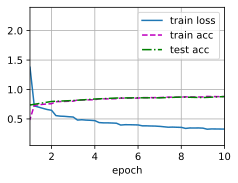

In [6]:
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

### 7.2 使用块的网络(VGG)

- 之前我们有提到网络层和块的概念，模块封装再复用的思想指导我们去思考如何设计一些通用的模板来指导深层神经网络的构建

- 使用块的想法最早可以追溯到VGG这个网络中，VGG的名字来源于创建团队是牛津大学的视觉几何组(visual geometry group)

#### 7.2.1 VGG块

- 经典的卷积神经网络的基本组成部分是：
    - 带填充的卷积层
    - 非线性激活函数
    - 汇聚层

- 一个VGG块就汇聚了一个这样的三层结构，类似堆积木一样的就可以通过预先定义好的VGG块进行拼接构建深度神经网络

- 下面是具体的实现，需要三个参数，卷积层的数量、输入通道数、输出通道数：

In [9]:
import torch
from torch import nn

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels # 这样设定如果在一个vgg block中的第二个卷积层开始，都只能做输出和输入通道数相同的卷积操作
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

#### 7.2.2 VGG网络

- VGG网络连接几个VGG块，剩下的全连接层部分和AlexNet类似

- 原始的VGG网络有5个卷积块，前两个块各有一个卷积层，后三个各有两个卷积层，第一个模块的输出通道是64，后续的模块通道数持续翻倍直到512
    - 因为总的来说这个网络包含了8个卷积层和3个全连接层，因此被称为VGG-11

- 下面的代码具体实现了VGG-11：

In [10]:
# 通过conv_arch这个元组管理具体的通道和卷积数量

conv_arch = ((1,64), (1,128), (2,256), (2,512), (2,512))

def vgg(conv_arch):
    con_blks = []
    in_channels = 1

    for (num_convs, out_channels) in conv_arch:
        con_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *con_blks, nn.Flatten(),
        nn.Linear(out_channels * 7 * 7, 4096),nn.ReLU(),nn.Dropout(0.5),
        nn.Linear(4096,4096),nn.ReLU(),nn.Dropout(0.5),
        nn.Linear(4096,10)
    )

net = vgg(conv_arch)

X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__,'output shape:\t',X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


#### 7.2.3 训练模型

- VGG-11的训练量更大，因此对现在的VGG进行一定的修改，具体来说就是将当前的输出通道数降低

loss 0.180, train acc 0.933, test acc 0.924
6534.1 examples/sec on cuda:1


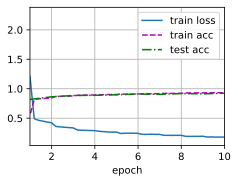

In [12]:
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)


lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

### 7.3 网络中的网络(NiN)

- LeNet、AlexNet和VGG都有一个共同的设计模式:通过一系列的卷积层与汇聚层来提取空间结构特征;然后通过全连接层对特征的表征进行处理

- NiN的思路是：
    - 前面三个的结构类似，前期的卷积看空间结构，后期的全连接看分类
    - 无法在前期就施加全连接，因为Flatten的操作会让图像的空间结构失去作用
    - NiN的作者认为，卷积运算只能做线性特征提取，表达能力有限
        - 这里补充说一点，卷积完通常都会加上激活，这样可以看成是非线性的表征，但问题在于NiN想实现的是单次感受野扩大的过程中就学习到非线性特征
    - 因此，NiN的思路就是在每个像素的通道上分别使用多层感知机(具体的实现方式就是1*1的卷积)